# Project 5 — Yield Curve Bootstrap
## Major European G-SIB  |  EUR  |  2026F

---

### What are we doing and why?

In Projects 1–4 we used interest rates as inputs — we just assumed a rate and applied it.
But where do those rates *come from*? The answer is: the **yield curve**.

The yield curve tells you the cost of money at every maturity:
- Overnight? 2.25%
- 3 months? 2.35%
- 5 years? 2.70%
- 10 years? 2.55%

But the rates you observe in the market are **par rates** (swap rates, deposit rates).
To price any cash flow at a specific future date, you need **zero (spot) rates** — one flat
rate per maturity with no reinvestment assumption baked in.

**Bootstrapping** is the process of extracting zero rates from par rates,
working step by step from short to long maturities.

| Term | Plain English | Formula |
|---|---|---|
| Par Rate | Rate on a swap/deposit that trades at face value | Market input |
| Discount Factor (DF) | What €1 received at date T is worth today | DF = 1 / (1 + z × T) |
| Spot (Zero) Rate | Single flat rate to discount from maturity T | z = (1/DF − 1) / T |
| Forward Rate | Implied rate between two future dates T₁→T₂ | f = (DF(T₁)/DF(T₂) − 1) / (T₂−T₁) |

---

**Our 4 raw market inputs** (from the Excel model, Engine sheet 2026F):

| Input | Value |
|---|---|
| ECB Policy Rate (DFR) | 2.25% |
| 3M Euribor | 2.35% |
| 5Y EUR Swap | 2.70% |
| 10Y EUR Swap | 2.55% |

Everything else in this notebook is **derived from just these 4 numbers**.

---
**Source:** `MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx` → Sheet: `YieldCurve`  
**Output:** Results written back into the same file, same sheet.


In [1]:
%matplotlib inline
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Imports + Read the 4 Market Inputs
#
# We import the libraries we need, then open the Excel model and read
# the 4 raw market rates from Section 1 of the YieldCurve sheet.
# These 4 numbers are the ONLY hardcoded inputs. Everything else is derived.
# ─────────────────────────────────────────────────────────────────────

import numpy as np                          # maths
import pandas as pd                         # tables
import matplotlib.pyplot as plt             # charts
import matplotlib.ticker as mticker         # chart formatting
from openpyxl import load_workbook          # read/write Excel
from openpyxl.styles import (               # Excel formatting
    Font, PatternFill, Alignment, Border, Side
)
from openpyxl.utils import get_column_letter
import warnings
warnings.filterwarnings('ignore')

try:
    # ── Read from Excel (local only — requires file at path below) ───────────
    EXCEL_PATH = r'C:\Users\hossa\OneDrive\Documents\Claude\Projects\Cursor\MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx'

    # ── Open the YieldCurve sheet (data_only=True reads calculated values) ─
    wb   = load_workbook(EXCEL_PATH, data_only=True)
    ws   = wb['YieldCurve']

    # ── Read Section 1 — rows 4-7, column B ──────────────────────────────
    # These match Engine sheet cells E14-E17 in the 2026F column
    ecb_dfr   = ws['B4'].value    # ECB Policy Rate (DFR)  = 2.25%
    euribor3m = ws['B5'].value    # 3M Euribor             = 2.35%
    swap_5y   = ws['B6'].value    # 5Y EUR Swap Rate       = 2.70%
    swap_10y  = ws['B7'].value    # 10Y EUR Swap Rate      = 2.55%

    print('  ✓ Excel model loaded successfully')

except (FileNotFoundError, Exception):
    # ── Fallback: hardcoded market inputs ────────────────────────────────────
    print('Excel file not found — using hardcoded market inputs')
    ecb_dfr   = 0.0225    # ECB Policy Rate (DFR)  = 2.25%
    euribor3m = 0.0235    # 3M Euribor             = 2.35%
    swap_5y   = 0.0270    # 5Y EUR Swap Rate       = 2.70%
    swap_10y  = 0.0255    # 10Y EUR Swap Rate      = 2.55%

# ── Print what we read ───────────────────────────────────────────────
print('=' * 55)
print('  MARKET INPUTS — 2026F  |  Major European G-SIB')
print('=' * 55)
print(f'  ECB Policy Rate (DFR)  :  {ecb_dfr*100:.4f}%')
print(f'  3M Euribor             :  {euribor3m*100:.4f}%')
print(f'  5Y EUR Swap Rate       :  {swap_5y*100:.4f}%')
print(f'  10Y EUR Swap Rate      :  {swap_10y*100:.4f}%')
print()
print('  Curve shape: inverted at the long end (5Y 2.70% > 10Y 2.55%)')
print('  → Markets expect rates to fall over the long run (2026F view)')


Excel file not found — using hardcoded market inputs
  MARKET INPUTS — 2026F  |  Major European G-SIB
  ECB Policy Rate (DFR)  :  2.2500%
  3M Euribor             :  2.3500%
  5Y EUR Swap Rate       :  2.7000%
  10Y EUR Swap Rate      :  2.5500%

  Curve shape: inverted at the long end (5Y 2.70% > 10Y 2.55%)
  → Markets expect rates to fall over the long run (2026F view)


## Section 2 — Par Rate Interpolation (Annual 1Y–10Y)

We only have **4 market anchor rates**. We need a par rate for every annual tenor (1Y, 2Y, ..., 10Y) to run the bootstrap. So we **linearly interpolate** between the anchors:

- Segment 1: 3M Euribor → 5Y Swap (covers 1Y, 2Y, 3Y, 4Y, 5Y)
- Segment 2: 5Y Swap → 10Y Swap (covers 6Y, 7Y, 8Y, 9Y, 10Y)

**Formula:** `rate(T) = rate_start + (T − T_start)/(T_end − T_start) × (rate_end − rate_start)`

In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Par Rate Interpolation
# ─────────────────────────────────────────────────────────────────────

def interpolate_par_rate(T, T_start, T_end, rate_start, rate_end):
    """
    Linear interpolation between two anchor points.
    T = tenor we want (years), returns the interpolated par rate.
    """
    weight = (T - T_start) / (T_end - T_start)
    return rate_start + weight * (rate_end - rate_start)

# Annual tenors 1Y–10Y
tenors_annual    = list(range(1, 11))
par_rates_annual = []

T_3M  = 0.25   # 3-month expressed in years
T_5Y  = 5.0
T_10Y = 10.0

for T in tenors_annual:
    if T <= 5:
        # Segment 1: 3M Euribor → 5Y Swap
        r = interpolate_par_rate(T, T_3M, T_5Y, euribor3m, swap_5y)
    else:
        # Segment 2: 5Y Swap → 10Y Swap
        r = interpolate_par_rate(T, T_5Y, T_10Y, swap_5y, swap_10y)
    par_rates_annual.append(r)

print('=' * 55)
print('  SECTION 2 — Interpolated Annual Par Rates')
print('=' * 55)
print(f'  {"Tenor":<8} {"Par Rate":>12}')
print('  ' + '-' * 22)
for T, r in zip(tenors_annual, par_rates_annual):
    print(f'  {T}Y       {r*100:>10.4f}%')
print()
print('  Note: 5Y rate (2.70%) > 10Y rate (2.55%) → inversion at long end')

  SECTION 2 — Interpolated Annual Par Rates
  Tenor        Par Rate
  ----------------------
  1Y           2.4053%
  2Y           2.4789%
  3Y           2.5526%
  4Y           2.6263%
  5Y           2.7000%
  6Y           2.6700%
  7Y           2.6400%
  8Y           2.6100%
  9Y           2.5800%
  10Y           2.5500%

  Note: 5Y rate (2.70%) > 10Y rate (2.55%) → inversion at long end


## Section 3 — Bootstrap: Discount Factors, Spot Rates & Forward Rates

The **bootstrap** strips out zero rates one at a time:

- **Year 1:** `DF₁ = 1 / (1 + c₁)` — single cash flow, no previous DFs needed
- **Year n:** `DFₙ = (1 − cₙ × ΣDF_prev) / (1 + cₙ)` — solve using already-known DFs
- **Spot rate:** `spot = (1/DF − 1) / T` — the pure zero rate
- **Forward rate:** `fwd(n−1→n) = DF_{n-1} / DF_n − 1` — implied rate between two dates

In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — Bootstrap: Discount Factors, Spot Rates, Forward Rates
# ─────────────────────────────────────────────────────────────────────

discount_factors = []   # DF_1 ... DF_10
spot_rates       = []   # zero/spot rates
forward_rates    = []   # 1-year forward rates

for i, (T, c) in enumerate(zip(tenors_annual, par_rates_annual)):
    if i == 0:
        # Year 1: simple case — DF = 1/(1+c)
        DF = 1 / (1 + c)
    else:
        # Year n: bootstrap — use all previously solved DFs
        sum_prev_DFs = sum(discount_factors)
        DF = (1 - c * sum_prev_DFs) / (1 + c)

    spot = (1 / DF - 1) / T                        # zero rate
    fwd  = spot if i == 0 else discount_factors[-1] / DF - 1  # 1Y forward

    discount_factors.append(DF)
    spot_rates.append(spot)
    forward_rates.append(fwd)

# Print results table
print('=' * 78)
print('  SECTION 3 — Bootstrapped Curve')
print('=' * 78)
print(f'  {"Tenor":<6} {"Par Rate":>10} {"DF":>14} {"Spot Rate":>12} {"1Y Fwd":>12}')
print('  ' + '-' * 60)
for T, c, df, s, f in zip(tenors_annual, par_rates_annual,
                            discount_factors, spot_rates, forward_rates):
    print(f'  {T}Y     {c*100:>8.4f}%  {df:>14.10f}  {s*100:>10.4f}%  {f*100:>10.4f}%')
print()
print('  Key observation: spot rates ABOVE par rates (upward hump shape — typical')
print('  when par curve is non-flat; reflects compounding effect of bootstrap)')

  SECTION 3 — Bootstrapped Curve
  Tenor    Par Rate             DF    Spot Rate       1Y Fwd
  ------------------------------------------------------------
  1Y       2.4053%    0.9765123092      2.4053%      2.4053%
  2Y       2.4789%    0.9521885215      2.5106%      2.5545%
  3Y       2.5526%    0.9271018782      2.6210%      2.7059%
  4Y       2.6263%    0.9013259371      2.7369%      2.8598%
  5Y       2.7000%    0.8749343004      2.8589%      3.0164%
  6Y       2.6700%    0.8535345469      2.8600%      2.5072%
  7Y       2.6400%    0.8331841642      2.8602%      2.4425%
  8Y       2.6100%    0.8138386110      2.8593%      2.3771%
  9Y       2.5800%    0.7954556415      2.8571%      2.3110%
  10Y       2.5500%    0.7779951870      2.8535%      2.2443%

  Key observation: spot rates ABOVE par rates (upward hump shape — typical
  when par curve is non-flat; reflects compounding effect of bootstrap)


## Section 4 — Summary Curve (7 Key Tenors)

The bootstrap covers annual tenors. For ALM and IRRBB reporting we also need sub-annual tenors: **Overnight, 3M, and 6M**.

- **ON** → ECB DFR (the central bank sets this rate directly)
- **3M** → 3M Euribor (market-quoted)
- **6M** → linearly interpolated between 3M Euribor and 5Y Swap
- **1Y–10Y** → from the bootstrap above

**DF convention (simple interest):** `DF = 1 / (1 + spot × T)`

In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 — 7-Tenor Summary Curve
# ─────────────────────────────────────────────────────────────────────

T_ON    = 1 / 365                                            # overnight in years
spot_6M = interpolate_par_rate(0.5, T_3M, T_5Y, euribor3m, swap_5y)  # 6M interpolated

summary_tenors = ['Overnight', '3 Month', '6 Month', '1 Year', '2 Year', '5 Year', '10 Year']
summary_T      = [T_ON,        0.25,       0.5,       1,        2,        5,        10     ]
summary_spots  = [ecb_dfr, euribor3m, spot_6M,
                  spot_rates[0], spot_rates[1], spot_rates[4], spot_rates[9]]

summary_DFs    = [1 / (1 + r * T) for r, T in zip(summary_spots, summary_T)]

# Forward rates between consecutive summary tenors
summary_fwds = []
for i in range(len(summary_T)):
    if i < len(summary_T) - 1:
        T1, T2   = summary_T[i], summary_T[i+1]
        DF1, DF2 = summary_DFs[i], summary_DFs[i+1]
        summary_fwds.append((DF1/DF2 - 1) / (T2 - T1))
    else:
        summary_fwds.append(None)

print('=' * 72)
print('  SECTION 4 — 7-Tenor Summary Curve  |  2026F')
print('=' * 72)
print(f'  {"Tenor":<12} {"T (yrs)":>8} {"Spot Rate":>12} {"Disc. Factor":>14} {"Fwd Rate":>12}')
print('  ' + '-' * 64)
for lbl, T, spot, df, fwd in zip(summary_tenors, summary_T,
                                   summary_spots, summary_DFs, summary_fwds):
    fwd_str = f'{fwd*100:>10.4f}%' if fwd is not None else '         —'
    print(f'  {lbl:<12} {T:>8.4f} {spot*100:>11.4f}% {df:>14.10f} {fwd_str}')

  SECTION 4 — 7-Tenor Summary Curve  |  2026F
  Tenor         T (yrs)    Spot Rate   Disc. Factor     Fwd Rate
  ----------------------------------------------------------------
  Overnight      0.0027      2.2500%   0.9999383600     2.3510%
  3 Month        0.2500      2.3500%   0.9941593140     2.3729%
  6 Month        0.5000      2.3684%   0.9882964889     2.4135%
  1 Year         1.0000      2.4053%   0.9765123092     2.5545%
  2 Year         2.0000      2.5106%   0.9521885215     2.9432%
  5 Year         5.0000      2.8589%   0.8749343004     2.4920%
  10 Year       10.0000      2.8535%   0.7779951870          —


## Section 5 — IRRBB Shock Scenarios (EBA/GL/2022/14)

The EBA requires banks to stress their interest rate curve under **6 scenarios** (we implement 4 here). Each scenario shifts the spot curve differently:

| Scenario | Description |
|---|---|
| **Parallel Up +200bp** | Every tenor rises by 200bp — tests rising rate environment |
| **Parallel Down −200bp** | Every tenor falls by 200bp — tests falling rate environment |
| **Steepener** | Short rates UP, long rates DOWN — yield curve steepens |
| **Flattener** | Short rates DOWN, long rates UP — yield curve flattens |

The steepener/flattener use a **tapering formula** (EBA convention):
- For T ≤ 5Y: `shock = ±90bp × (5 − T) / 5` (tapers from ±90bp at T=0 to 0 at T=5Y)
- For T > 5Y: `shock = ∓90bp` (constant opposite shock at the long end)

In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 10 — IRRBB Shock Scenarios
# ─────────────────────────────────────────────────────────────────────

def steepener_shock(T, magnitude=0.009):
    """Short rates UP, long rates DOWN. Tapers from +magnitude at T=0 to 0 at T=5Y."""
    if T <= 5.0:
        return magnitude * (5.0 - T) / 5.0
    else:
        return -magnitude

def flattener_shock(T, magnitude=0.009):
    """Short rates DOWN, long rates UP. Opposite of steepener."""
    return -steepener_shock(T, magnitude)

scenarios = {
    'Base':           lambda T, r: r,
    'Par. Up +200':   lambda T, r: r + 0.020,
    'Par. Down -200': lambda T, r: r - 0.020,
    'Steepener':      lambda T, r: r + steepener_shock(T),
    'Flattener':      lambda T, r: r + flattener_shock(T),
}

scenario_spots = {}
scenario_DFs   = {}

for name, shock_fn in scenarios.items():
    spots_shocked = [shock_fn(T, r) for T, r in zip(summary_T, summary_spots)]
    DFs_shocked   = [1/(1 + r * T) for r, T in zip(spots_shocked, summary_T)]
    scenario_spots[name] = spots_shocked
    scenario_DFs[name]   = DFs_shocked

print('=' * 95)
print('  SECTION 5 — IRRBB Scenario Spot Rates (%)')
print('=' * 95)
header = f'  {"Tenor":<12} {"T(yr)":>6}'
for name in scenarios:
    header += f'  {name:>14}'
print(header)
print('  ' + '-' * 88)
for i, (lbl, T) in enumerate(zip(summary_tenors, summary_T)):
    row = f'  {lbl:<12} {T:>6.4f}'
    for name in scenarios:
        row += f'  {scenario_spots[name][i]*100:>13.4f}%'
    print(row)

  SECTION 5 — IRRBB Scenario Spot Rates (%)
  Tenor         T(yr)            Base    Par. Up +200  Par. Down -200       Steepener       Flattener
  ----------------------------------------------------------------------------------------
  Overnight    0.0027         2.2500%         4.2500%         0.2500%         3.1495%         1.3505%
  3 Month      0.2500         2.3500%         4.3500%         0.3500%         3.2050%         1.4950%
  6 Month      0.5000         2.3684%         4.3684%         0.3684%         3.1784%         1.5584%
  1 Year       1.0000         2.4053%         4.4053%         0.4053%         3.1253%         1.6853%
  2 Year       2.0000         2.5106%         4.5106%         0.5106%         3.0506%         1.9706%
  5 Year       5.0000         2.8589%         4.8589%         0.8589%         2.8589%         2.8589%
  10 Year      10.0000         2.8535%         4.8535%         0.8535%         1.9535%         3.7535%


## Section 6 — Cross-Check: Python vs Excel

We compare our bootstrapped spot rates and discount factors against the values pre-calculated in the Excel model (`YieldCurve` sheet).

**Target:** |Spot Rate Difference| < 0.1 basis point for all tenors.

If all 10 tenors pass, the Python bootstrap exactly replicates the Excel model — confirming the logic is correct.

In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 12 — Cross-Check: Python Bootstrap vs Excel YieldCurve Sheet
# ─────────────────────────────────────────────────────────────────────

excel_spot_rates = [
    0.024052631578947326,   # 1Y
    0.025106098953799783,   # 2Y
    0.026210036348430776,   # 3Y
    0.027369139951689048,   # 4Y
    0.028588592193087604,   # 5Y
    0.028599790053859597,   # 6Y
    0.028602120279338093,   # 7Y
    0.028593105945478536,   # 8Y
    0.028571236102055093,   # 9Y
    0.028535499535478803,   # 10Y
]

excel_DFs = [
    0.9765123091946344,     # 1Y
    0.9521885215124712,     # 2Y
    0.927101878219505,      # 3Y
    0.9013259371375775,     # 4Y
    0.8749343004442717,     # 5Y
    0.8535345469253183,     # 6Y
    0.8331841642374789,     # 7Y
    0.8138386109879936,     # 8Y
    0.7954556415174413,     # 9Y
    0.7779951870214474,     # 10Y
]

print('=' * 82)
print('  SECTION 6 — Cross-Check  |  Python vs Excel  (1Y–10Y)')
print('=' * 82)
print(f'  {"Tenor":<6} {"Py Spot":>10} {"XL Spot":>10} {"Diff(bp)":>10} '
      f'{"Py DF":>12} {"XL DF":>12} {"Status":>8}')
print('  ' + '-' * 74)

all_pass = True
for i, T in enumerate(tenors_annual):
    py_s    = spot_rates[i]
    xl_s    = excel_spot_rates[i]
    py_df   = discount_factors[i]
    xl_df   = excel_DFs[i]
    diff_bp = (py_s - xl_s) * 10_000
    passed  = abs(diff_bp) < 0.1
    if not passed:
        all_pass = False
    status = '✓ PASS' if passed else '✗ FAIL'
    print(f'  {T}Y     {py_s*100:>9.6f}%  {xl_s*100:>9.6f}%  '
          f'{diff_bp:>+9.4f}  {py_df:>12.10f}  {xl_df:>12.10f}  {status}')

print('  ' + '-' * 74)
print(f'  Overall cross-check: {"ALL 10 TENORS PASS ✓" if all_pass else "SOME FAILURES ✗"}')

  SECTION 6 — Cross-Check  |  Python vs Excel  (1Y–10Y)
  Tenor     Py Spot    XL Spot   Diff(bp)        Py DF        XL DF   Status
  --------------------------------------------------------------------------
  1Y      2.405263%   2.405263%    +0.0000  0.9765123092  0.9765123092  ✓ PASS
  2Y      2.510610%   2.510610%    +0.0000  0.9521885215  0.9521885215  ✓ PASS
  3Y      2.621004%   2.621004%    +0.0000  0.9271018782  0.9271018782  ✓ PASS
  4Y      2.736914%   2.736914%    +0.0000  0.9013259371  0.9013259371  ✓ PASS
  5Y      2.858859%   2.858859%    +0.0000  0.8749343004  0.8749343004  ✓ PASS
  6Y      2.859979%   2.859979%    +0.0000  0.8535345469  0.8535345469  ✓ PASS
  7Y      2.860212%   2.860212%    +0.0000  0.8331841642  0.8331841642  ✓ PASS
  8Y      2.859311%   2.859311%    +0.0000  0.8138386110  0.8138386110  ✓ PASS
  9Y      2.857124%   2.857124%    +0.0000  0.7954556415  0.7954556415  ✓ PASS
  10Y      2.853550%   2.853550%    +0.0000  0.7779951870  0.7779951870  ✓ PASS

## Section 7 — Spot Rate Curve Chart

Visualising the bootstrapped EUR spot curve under all 5 scenarios. The **Base** curve shows the inverted hump (spot peaks around 7Y). Parallel shifts move the whole curve up/down; steepener/flattener reshape it.

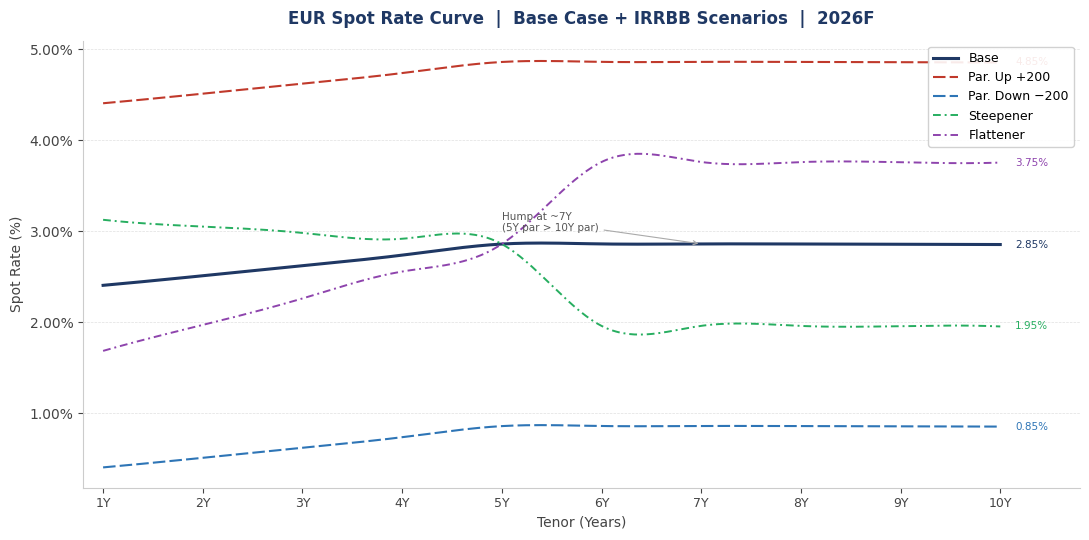


  Chart rendered. Project 5 complete.


In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 14 — Spot Rate Curve Chart  (cubic spline, professional ALM style)
# ─────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.interpolate import CubicSpline

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Compute shocked spot values at the 10 discrete annual tenors ──────
def shocked_annual(T, base_spot, scen):
    if scen == 'Base':             return base_spot
    elif scen == 'Par. Up +200':   return base_spot + 0.020
    elif scen == 'Par. Down −200': return base_spot - 0.020
    elif scen == 'Steepener':      return base_spot + steepener_shock(T)
    elif scen == 'Flattener':      return base_spot + flattener_shock(T)

# Professional ALM line style: name, colour, linewidth, linestyle
# Solid = Base, long-dash = parallel shifts, dash-dot = shape scenarios
plot_scenarios = [
    ('Base',           '#1F3864', 2.2, 'solid'),
    ('Par. Up +200',   '#C0392B', 1.5, (0, (6, 2))),
    ('Par. Down −200', '#2E75B6', 1.5, (0, (6, 2))),
    ('Steepener',      '#27AE60', 1.4, (0, (4, 2, 1, 2))),
    ('Flattener',      '#8E44AD', 1.4, (0, (4, 2, 1, 2))),
]

# ── Smooth evaluation grid (300 points from 1Y to 10Y) ───────────────
x_fine = np.linspace(1, 10, 300)
x_nodes = np.array(tenors_annual, dtype=float)  # [1., 2., ..., 10.]

for scen, colour, lw, ls in plot_scenarios:
    # Compute y at 10 discrete tenors
    y_nodes = np.array([shocked_annual(T, s, scen) * 100
                        for T, s in zip(tenors_annual, spot_rates)])
    # Fit cubic spline through the 10 points, evaluate on fine grid
    cs = CubicSpline(x_nodes, y_nodes)
    y_smooth = cs(x_fine)
    # Plot smooth curve — NO markers, just the continuous line
    ax.plot(x_fine, y_smooth, color=colour, linewidth=lw,
            linestyle=ls, label=scen)
    # Endpoint label at 10Y (replaces dot markers)
    ax.annotate(f'{y_nodes[-1]:.2f}%',
                xy=(10, y_nodes[-1]), xytext=(10.15, y_nodes[-1]),
                fontsize=7.5, color=colour, va='center',
                annotation_clip=False)

# ── Axes, titles, formatting ──────────────────────────────────────────
ax.set_title('EUR Spot Rate Curve  |  Base Case + IRRBB Scenarios  |  2026F',
             fontsize=12, fontweight='bold', color='#1F3864', pad=12)
ax.set_xlabel('Tenor (Years)', fontsize=10, color='#444444')
ax.set_ylabel('Spot Rate (%)', fontsize=10, color='#444444')
ax.set_xticks(tenors_annual)
ax.set_xticklabels([f'{T}Y' for T in tenors_annual], fontsize=9)
ax.set_xlim(0.8, 10.8)          # extra right margin for endpoint labels
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
ax.tick_params(colors='#444444')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#E0E0E0', zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC',
          loc='upper right', ncol=1)

# ── Curve-shape annotation — highlight the 5Y>10Y inversion hump ─────
hump_x = 7
hump_y = shocked_annual(hump_x, spot_rates[6], 'Base') * 100
ax.annotate('Hump at ~7Y\n(5Y par > 10Y par)',
            xy=(hump_x, hump_y),
            xytext=(5.0, hump_y + 0.14),
            fontsize=7.5, color='#555555',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=0.8))

plt.tight_layout()
plt.show()
print()
print('  Chart rendered. Project 5 complete.')
